In [5]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import KFold, train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import datetime
import json
import glob

# =========================
# 0. 全局配置
# =========================
SEED = 42
TEST_RATIO = 0.15
N_SPLITS = 5
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 100
NUM_WORKERS = 0
PRINT_EVERY = 10
THRESHOLDS = np.arange(0.30, 0.71, 0.05)
SMOKE_TEST = False

BASE_DIR = Path.cwd()
CSV_PATH = BASE_DIR / "pokemon.csv"
IMG_DIR = BASE_DIR / "images"
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR = BASE_DIR / "model"
MODEL_DIR.mkdir(exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if SMOKE_TEST:
    EPOCHS = 3


# =========================
# 1. 工具函数
# =========================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def build_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return train_transform, eval_transform


def split_train_val_test(dataset, test_ratio, seed):
    indices = np.arange(len(dataset))
    train_val_indices, test_indices = train_test_split(
        indices,
        test_size=test_ratio,
        random_state=seed,
        shuffle=True,
    )

    train_val_indices = np.asarray(train_val_indices)
    test_indices = np.asarray(test_indices)

    assert len(set(train_val_indices).intersection(set(test_indices))) == 0, "train_val 和 test 发生重叠"
    assert len(train_val_indices) + len(test_indices) == len(dataset), "切分后样本总数不一致" 

    return train_val_indices, test_indices


def safe_mean_average_precision(labels, probs):
    ap_scores = []
    for class_idx in range(labels.shape[1]):
        y_true = labels[:, class_idx]
        if y_true.sum() == 0:
            continue
        ap_scores.append(average_precision_score(y_true, probs[:, class_idx]))
    return float(np.mean(ap_scores)) if ap_scores else 0.0


def compute_pos_weight(dataset, indices):
    label_matrix = dataset.label_matrix[indices]
    pos_count = label_matrix.sum(axis=0)
    neg_count = len(indices) - pos_count
    weights = neg_count / np.maximum(pos_count, 1.0)
    return torch.tensor(weights, dtype=torch.float32)


def compute_f1_metrics(probs, labels, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "macro_f1": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "micro_f1": float(f1_score(labels, preds, average="micro", zero_division=0)),
    }

def compute_test_detail_metrics(probs, labels, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "macro_f1": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "micro_f1": float(f1_score(labels, preds, average="micro", zero_division=0)),
        "precision": float(precision_score(labels, preds, average="macro", zero_division=0)),
        "recall": float(recall_score(labels, preds, average="macro", zero_division=0)),
        "class_f1": f1_score(labels, preds, average=None, zero_division=0).tolist(),
    }

def find_best_threshold(probs, labels, thresholds):
    best = {
        "threshold": float(thresholds[0]),
        "macro_f1": -1.0,
        "micro_f1": -1.0,
    }

    for threshold in thresholds:
        metrics = compute_f1_metrics(probs, labels, threshold)

        better_macro = metrics["macro_f1"] > best["macro_f1"] + 1e-12
        same_macro = abs(metrics["macro_f1"] - best["macro_f1"]) <= 1e-12
        better_micro = metrics["micro_f1"] > best["micro_f1"] + 1e-12

        if better_macro or (same_macro and better_micro):
            best = {
                "threshold": float(threshold),
                "macro_f1": metrics["macro_f1"],
                "micro_f1": metrics["micro_f1"],
            }

    return best


def evaluate(model, loader, device, criterion=None):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(imgs)
            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * imgs.size(0)
                total_samples += imgs.size(0)

            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())

    probs = np.vstack(all_probs)
    labels = np.vstack(all_labels).astype(int)

    return {
        "loss": total_loss / max(total_samples, 1),
        "mAP": safe_mean_average_precision(labels, probs),
        "probs": probs,
        "labels": labels,
    }


def summarize_metric(values):
    values = np.asarray(values, dtype=np.float64)
    mean = float(values.mean())
    std = float(values.std(ddof=1)) if len(values) > 1 else 0.0
    return mean, std

In [6]:
# =========================
# 2. 数据集定义
# =========================
class PokemonDataset(Dataset):
    def __init__(self, csv_file, img_dir):
        self.csv_file = Path(csv_file)
        self.img_dir = Path(img_dir)
        self.df = pd.read_csv(self.csv_file)

        self.types = [
            "Grass", "Poison", "Fire", "Flying", "Water", "Bug", "Normal", "Electric",
            "Ground", "Fairy", "Fighting", "Psychic", "Rock", "Steel", "Ice", "Ghost",
            "Dragon", "Dark"
        ]
        self.type2idx = {t: i for i, t in enumerate(self.types)}
        self.label_matrix = self._build_label_matrix()

    def _build_label_matrix(self):
        label_matrix = np.zeros((len(self.df), len(self.types)), dtype=np.float32)
        for row_idx, row in self.df.iterrows():
            t1 = row["Type1"]
            t2 = row["Type2"]
            if t1 in self.type2idx:
                label_matrix[row_idx, self.type2idx[t1]] = 1.0
            if isinstance(t2, str) and t2 in self.type2idx:
                label_matrix[row_idx, self.type2idx[t2]] = 1.0
        return label_matrix

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]["Name"].lower() + ".png"
        img_path = self.img_dir / img_name
        with Image.open(img_path) as img:
            image = img.convert("RGB")
        label = torch.from_numpy(self.label_matrix[idx].copy())
        return image, label


class PokemonSubsetDataset(Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[int(self.indices[idx])]
        if self.transform is not None:
            image = self.transform(image)
        return image, label.float()

In [7]:
# =========================
# 3. 模型定义
# =========================
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
        )
        self.shortcut = nn.Sequential()
        if in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1),
                nn.BatchNorm2d(out_c),
            )

    def forward(self, x):
        return F.relu(self.conv(x) + self.shortcut(x))


class PokemonModel(nn.Module):
    def __init__(self, use_res=False, pool_type="GAP", num_classes=18):
        super().__init__()

        def make_block(in_c, out_c):
            if use_res:
                return ResidualBlock(in_c, out_c)
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
            )

        self.enc = nn.Sequential(
            make_block(3, 32), nn.MaxPool2d(2),
            make_block(32, 64), nn.MaxPool2d(2),
            make_block(64, 128), nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d(1) if pool_type == "GAP" else nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.fc(x)

In [8]:
# =========================
# 4. 训练与评估主流程
# =========================
def build_loader(dataset, indices, transform, batch_size, shuffle):
    subset = PokemonSubsetDataset(dataset, indices, transform=transform)
    return DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total_samples += imgs.size(0)

    return total_loss / max(total_samples, 1)


def run_cv_experiment(config, dataset, train_val_indices, train_transform, eval_transform):
    print(f"\n{'=' * 24} {config['name']} | 5-Fold CV {'=' * 24}")
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    fold_records = []
    epoch_history = []   # 新增：存每个 epoch 的记录
    train_val_indices = np.asarray(train_val_indices)

    for fold_id, (train_pos, val_pos) in enumerate(kf.split(train_val_indices), start=1):
        fold_train_indices = train_val_indices[train_pos]
        fold_val_indices = train_val_indices[val_pos]

        train_loader = build_loader(dataset, fold_train_indices, train_transform, BATCH_SIZE, True)
        val_loader = build_loader(dataset, fold_val_indices, eval_transform, BATCH_SIZE, False)

        pos_weight = compute_pos_weight(dataset, fold_train_indices).to(DEVICE)
        model = PokemonModel(use_res=config["use_res"], pool_type=config["pool_type"]).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_record = {
            "epoch": 1,
            "threshold": float(THRESHOLDS[0]),
            "val_loss": float("inf"),
            "macro_f1": -1.0,
            "micro_f1": -1.0,
            "mAP": 0.0,
        }

        print(f"Fold {fold_id}/{N_SPLITS}")
        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
            val_result = evaluate(model, val_loader, DEVICE, criterion=criterion)
            threshold_result = find_best_threshold(val_result["probs"], val_result["labels"], THRESHOLDS)

            current_record = {
                "epoch": epoch,
                "threshold": threshold_result["threshold"],
                "val_loss": val_result["loss"],
                "macro_f1": threshold_result["macro_f1"],
                "micro_f1": threshold_result["micro_f1"],
                "mAP": val_result["mAP"],
            }

            # 新增：保存 epoch 历史
            epoch_history.append({
                "experiment": config["name"],
                "fold": fold_id,
                "epoch": epoch,
                "train_loss": float(train_loss),
                "val_loss": float(val_result["loss"]),
                "macro_f1": float(threshold_result["macro_f1"]),
                "micro_f1": float(threshold_result["micro_f1"]),
                "mAP": float(val_result["mAP"]),
                "threshold": float(threshold_result["threshold"]),
            })

            better_macro = current_record["macro_f1"] > best_record["macro_f1"] + 1e-12
            same_macro = abs(current_record["macro_f1"] - best_record["macro_f1"]) <= 1e-12
            lower_loss = current_record["val_loss"] < best_record["val_loss"] - 1e-12

            if better_macro or (same_macro and lower_loss):
                best_record.update(current_record)

            if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == EPOCHS:
                print(
                    f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | "
                    f"Val Loss: {val_result['loss']:.4f} | "
                    f"Macro F1: {current_record['macro_f1']:.4f} | "
                    f"Micro F1: {current_record['micro_f1']:.4f} | "
                    f"mAP: {current_record['mAP']:.4f} | "
                    f"Thr: {current_record['threshold']:.2f}"
                )

        fold_summary = {
            "fold": fold_id,
            "best_epoch": int(best_record["epoch"]),
            "best_threshold": float(best_record["threshold"]),
            "val_loss": float(best_record["val_loss"]),
            "macro_f1": float(best_record["macro_f1"]),
            "micro_f1": float(best_record["micro_f1"]),
            "mAP": float(best_record["mAP"]),
        }
        fold_records.append(fold_summary)

        print(
            f"Fold {fold_id} Best | Epoch: {fold_summary['best_epoch']} | "
            f"Val Loss: {fold_summary['val_loss']:.4f} | "
            f"Macro F1: {fold_summary['macro_f1']:.4f} | "
            f"Micro F1: {fold_summary['micro_f1']:.4f} | "
            f"mAP: {fold_summary['mAP']:.4f} | "
            f"Thr: {fold_summary['best_threshold']:.2f}"
        )

    macro_mean, macro_std = summarize_metric([x["macro_f1"] for x in fold_records])
    micro_mean, micro_std = summarize_metric([x["micro_f1"] for x in fold_records])
    map_mean, map_std = summarize_metric([x["mAP"] for x in fold_records])
    best_epoch_final = int(np.median([x["best_epoch"] for x in fold_records]))
    best_threshold_final = float(np.median([x["best_threshold"] for x in fold_records]))

    cv_summary = {
        "name": config["name"],
        "cv_macro_mean": macro_mean,
        "cv_macro_std": macro_std,
        "cv_micro_mean": micro_mean,
        "cv_micro_std": micro_std,
        "cv_map_mean": map_mean,
        "cv_map_std": map_std,
        "best_epoch_final": best_epoch_final,
        "best_threshold_final": best_threshold_final,
        "fold_records": fold_records,
        "history_df": pd.DataFrame(epoch_history),   # 新增
    }

    print(
        f"\nCV Summary for {config['name']} | "
        f"Macro F1: {macro_mean:.4f} +/- {macro_std:.4f} | "
        f"Micro F1: {micro_mean:.4f} +/- {micro_std:.4f} | "
        f"mAP: {map_mean:.4f} +/- {map_std:.4f} | "
        f"Best Epoch(median): {best_epoch_final} | "
        f"Best Thr(median): {best_threshold_final:.2f}"
    )
    return cv_summary

def build_model_save_path(config):
    safe_name = config["name"].lower().replace(" + ", "_").replace(" ", "_")
    return MODEL_DIR / f"{safe_name}.pth"

def retrain_and_test(config, dataset, train_val_indices, test_indices, best_epoch, best_threshold, train_transform, eval_transform):
    print(f"\n{'-' * 20} Retrain on full train_val: {config['name']} {'-' * 20}")

    train_loader = build_loader(dataset, train_val_indices, train_transform, BATCH_SIZE, True)
    test_loader = build_loader(dataset, test_indices, eval_transform, BATCH_SIZE, False)

    pos_weight = compute_pos_weight(dataset, train_val_indices).to(DEVICE)
    model = PokemonModel(use_res=config["use_res"], pool_type=config["pool_type"]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    for epoch in range(1, best_epoch + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == best_epoch:
            print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f}")

    test_result = evaluate(model, test_loader, DEVICE, criterion=criterion)
    test_metrics = compute_test_detail_metrics(
        test_result["probs"],
        test_result["labels"],
        best_threshold,
    )

    model_path = build_model_save_path(config)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "config": config,
        "best_epoch": best_epoch,
        "best_threshold": best_threshold,
        "test_loss": float(test_result["loss"]),
        "test_macro_f1": float(test_metrics["macro_f1"]),
        "test_micro_f1": float(test_metrics["micro_f1"]),
        "test_precision": float(test_metrics["precision"]),
        "test_recall": float(test_metrics["recall"]),
        "test_class_f1": test_metrics["class_f1"],
        "test_mAP": float(test_result["mAP"]),
        "class_names": dataset.types,
    }
    torch.save(checkpoint, model_path)

    test_summary = {
        "test_loss": float(test_result["loss"]),
        "test_macro_f1": float(test_metrics["macro_f1"]),
        "test_micro_f1": float(test_metrics["micro_f1"]),
        "test_precision": float(test_metrics["precision"]),
        "test_recall": float(test_metrics["recall"]),
        "test_class_f1": test_metrics["class_f1"],
        "test_mAP": float(test_result["mAP"]),
        "model_path": str(model_path),
    }

    print(
        f"Test Result | Loss: {test_summary['test_loss']:.4f} | "
        f"Macro F1: {test_summary['test_macro_f1']:.4f} | "
        f"Micro F1: {test_summary['test_micro_f1']:.4f} | "
        f"Precision: {test_summary['test_precision']:.4f} | "
        f"Recall: {test_summary['test_recall']:.4f} | "
        f"mAP: {test_summary['test_mAP']:.4f} | "
        f"Thr: {best_threshold:.2f}"
    )
    print(f"Model saved to: {model_path}")

    return test_summary




# =========================
# 5. 主程序
# =========================
def main():
    set_seed(SEED)

    if not CSV_PATH.exists():
        raise FileNotFoundError(f"找不到 CSV 文件: {CSV_PATH}")
    if not IMG_DIR.exists():
        raise FileNotFoundError(f"找不到图片目录: {IMG_DIR}")

    print(f"Using device: {DEVICE}")
    print(f"Data root: {BASE_DIR}")
    print(f"CSV path : {CSV_PATH}")
    print(f"Image dir: {IMG_DIR}")
    print(f"SMOKE_TEST={SMOKE_TEST}, EPOCHS={EPOCHS}")

    dataset = PokemonDataset(CSV_PATH, IMG_DIR)
    class_names = dataset.types
    train_transform, eval_transform = build_transforms()
    train_val_indices, test_indices = split_train_val_test(dataset, TEST_RATIO, SEED)

    print(f"Total samples    : {len(dataset)}")
    print(f"Train/Val samples: {len(train_val_indices)}")
    print(f"Test samples     : {len(test_indices)}")

    experiments = [
        {"name": "Plain + GAP", "use_res": False, "pool_type": "GAP"},
        {"name": "Residual + GAP", "use_res": True, "pool_type": "GAP"},
        {"name": "Plain + GMP", "use_res": False, "pool_type": "GMP"},
    ]

    final_rows = []
    final_rows_raw = []
    all_histories = []

    for config in experiments:
        cv_summary = run_cv_experiment(
            config=config,
            dataset=dataset,
            train_val_indices=train_val_indices,
            train_transform=train_transform,
            eval_transform=eval_transform,
        )

        test_summary = retrain_and_test(
            config=config,
            dataset=dataset,
            train_val_indices=train_val_indices,
            test_indices=test_indices,
            best_epoch=cv_summary["best_epoch_final"],
            best_threshold=cv_summary["best_threshold_final"],
            train_transform=train_transform,
            eval_transform=eval_transform,
        )

        all_histories.append(cv_summary["history_df"])

        final_rows_raw.append({
            "Experiment": config["name"],
            "cv_macro_mean": cv_summary["cv_macro_mean"],
            "cv_macro_std": cv_summary["cv_macro_std"],
            "cv_micro_mean": cv_summary["cv_micro_mean"],
            "cv_micro_std": cv_summary["cv_micro_std"],
            "cv_map_mean": cv_summary["cv_map_mean"],
            "cv_map_std": cv_summary["cv_map_std"],
            "best_epoch": cv_summary["best_epoch_final"],
            "best_threshold": cv_summary["best_threshold_final"],
            "test_macro_f1": test_summary["test_macro_f1"],
            "test_micro_f1": test_summary["test_micro_f1"],
            "test_precision": test_summary["test_precision"],
            "test_recall": test_summary["test_recall"],
            "test_class_f1": test_summary["test_class_f1"],
            "test_mAP": test_summary["test_mAP"],
            "model_path": test_summary["model_path"],
        })

        final_rows.append({
            "Experiment": config["name"],
            "CV Macro F1": f"{cv_summary['cv_macro_mean']:.4f} +/- {cv_summary['cv_macro_std']:.4f}",
            "CV Micro F1": f"{cv_summary['cv_micro_mean']:.4f} +/- {cv_summary['cv_micro_std']:.4f}",
            "CV mAP": f"{cv_summary['cv_map_mean']:.4f} +/- {cv_summary['cv_map_std']:.4f}",
            "Best Epoch": cv_summary["best_epoch_final"],
            "Best Threshold": round(cv_summary["best_threshold_final"], 2),
            "Test Macro F1": round(test_summary["test_macro_f1"], 4),
            "Test Micro F1": round(test_summary["test_micro_f1"], 4),
            "Test Precision": round(test_summary["test_precision"], 4),
            "Test Recall": round(test_summary["test_recall"], 4),
            "Test mAP": round(test_summary["test_mAP"], 4),
        })

    summary_df = pd.DataFrame(final_rows)
    summary_raw_df = pd.DataFrame(final_rows_raw)
    history_df = pd.concat(all_histories, ignore_index=True)

    print(f"\n{'=' * 24} Final Summary {'=' * 24}")
    print(summary_df.to_string(index=False))

    return summary_df, summary_raw_df, history_df, class_names

summary_df, summary_raw_df, history_df, class_names = main()


Using device: cuda
Data root: C:\Users\KangjieLU\Pokemon_Project
CSV path : C:\Users\KangjieLU\Pokemon_Project\pokemon.csv
Image dir: C:\Users\KangjieLU\Pokemon_Project\images
SMOKE_TEST=False, EPOCHS=100
Total samples    : 809
Train/Val samples: 687
Test samples     : 122

======================== Plain + GAP | 5-Fold CV ========================
Fold 1/5
Epoch 01 | Train Loss: 1.2690 | Val Loss: 1.2983 | Macro F1: 0.1504 | Micro F1: 0.1529 | mAP: 0.1680 | Thr: 0.30
Epoch 10 | Train Loss: 1.1426 | Val Loss: 1.2400 | Macro F1: 0.2098 | Micro F1: 0.2172 | mAP: 0.2323 | Thr: 0.50
Epoch 20 | Train Loss: 1.1055 | Val Loss: 1.2551 | Macro F1: 0.2172 | Micro F1: 0.1854 | mAP: 0.2250 | Thr: 0.45
Epoch 30 | Train Loss: 1.0800 | Val Loss: 1.2026 | Macro F1: 0.2462 | Micro F1: 0.2819 | mAP: 0.2524 | Thr: 0.60
Epoch 40 | Train Loss: 1.0645 | Val Loss: 1.2523 | Macro F1: 0.2075 | Micro F1: 0.1833 | mAP: 0.2585 | Thr: 0.35
Epoch 50 | Train Loss: 1.0366 | Val Loss: 1.1860 | Macro F1: 0.2555 | Micro F

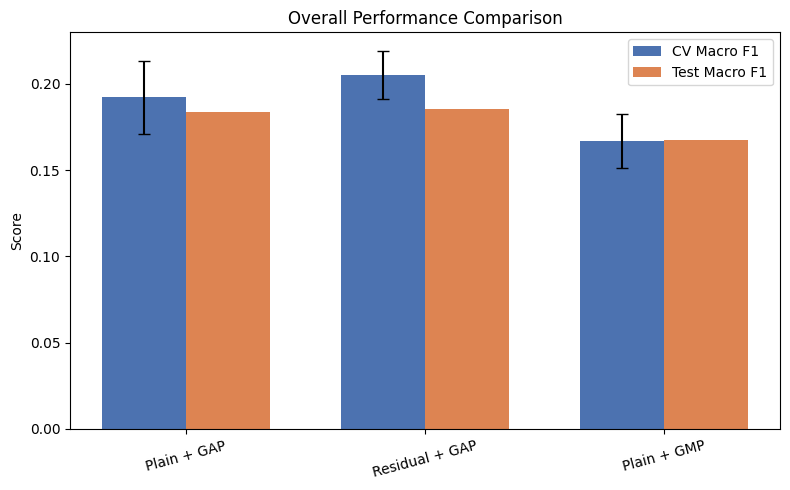

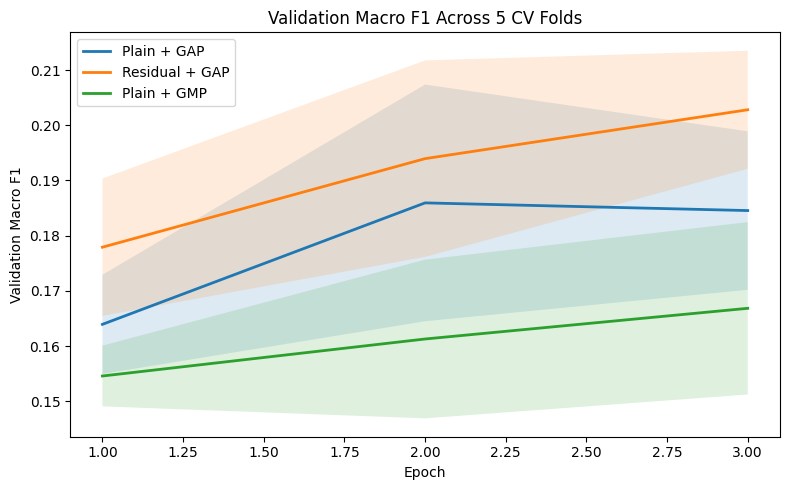

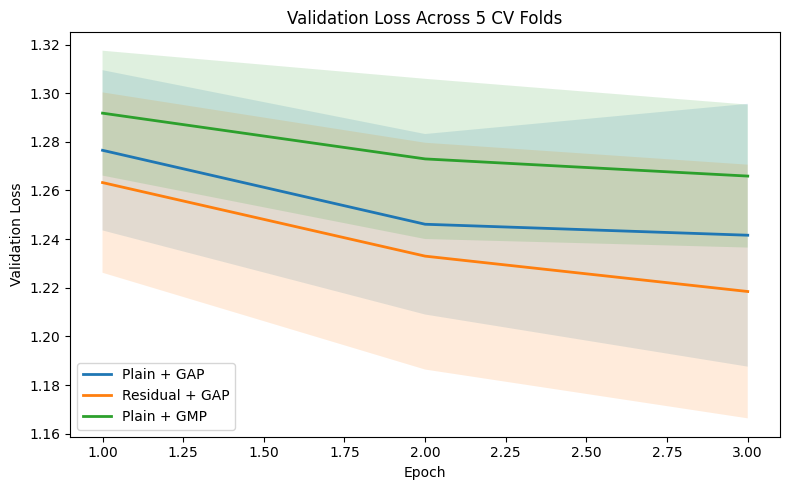

In [5]:
def plot_main_results(summary_raw_df):
    x = np.arange(len(summary_raw_df))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(
        x - width / 2,
        summary_raw_df["cv_macro_mean"],
        width,
        yerr=summary_raw_df["cv_macro_std"],
        capsize=4,
        label="CV Macro F1",
        color="#4C72B0",
    )
    plt.bar(
        x + width / 2,
        summary_raw_df["test_macro_f1"],
        width,
        label="Test Macro F1",
        color="#DD8452",
    )

    plt.xticks(x, summary_raw_df["Experiment"], rotation=15)
    plt.ylabel("Score")
    plt.title("Overall Performance Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "main_results.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_main_results(summary_raw_df)

def plot_mean_curve(history_df, metric, ylabel, filename):
    grouped = (
        history_df.groupby(["experiment", "epoch"])[metric]
        .agg(["mean", "std"])
        .reset_index()
    )

    plt.figure(figsize=(8, 5))

    for exp in history_df["experiment"].unique():
        sub = grouped[grouped["experiment"] == exp]
        x = sub["epoch"].to_numpy()
        y = sub["mean"].to_numpy()
        s = sub["std"].fillna(0).to_numpy()

        plt.plot(x, y, linewidth=2, label=exp)
        plt.fill_between(x, y - s, y + s, alpha=0.15)

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} Across 5 CV Folds")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_mean_curve(history_df, "macro_f1", "Validation Macro F1", "val_macro_f1_curve.png")
plot_mean_curve(history_df, "val_loss", "Validation Loss", "val_loss_curve.png")

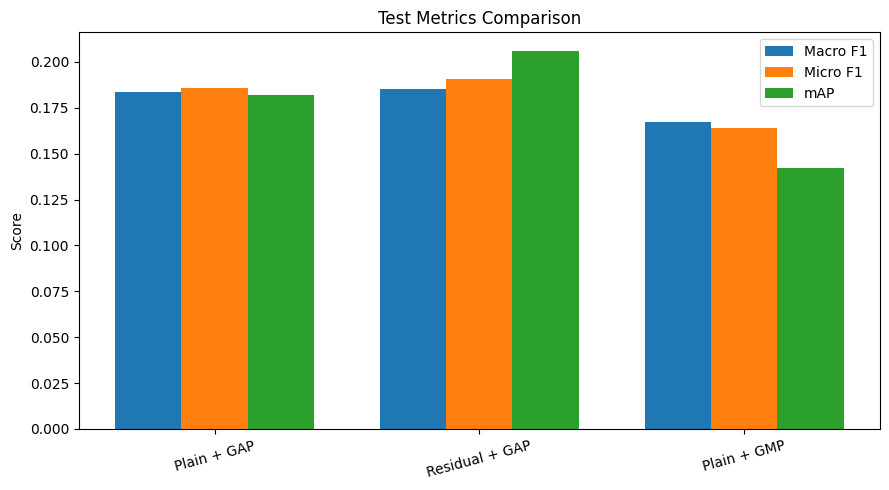

In [7]:
def plot_test_metrics(summary_raw_df):
    metrics = ["test_macro_f1", "test_micro_f1", "test_mAP"]
    labels = ["Macro F1", "Micro F1", "mAP"]

    x = np.arange(len(summary_raw_df))
    width = 0.25

    plt.figure(figsize=(9, 5))

    for i, (col, label) in enumerate(zip(metrics, labels)):
        plt.bar(
            x + (i - 1) * width,
            summary_raw_df[col],
            width,
            label=label,
        )

    plt.xticks(x, summary_raw_df["Experiment"], rotation=15)
    plt.ylabel("Score")
    plt.title("Test Metrics Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "test_metrics.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_test_metrics(summary_raw_df)


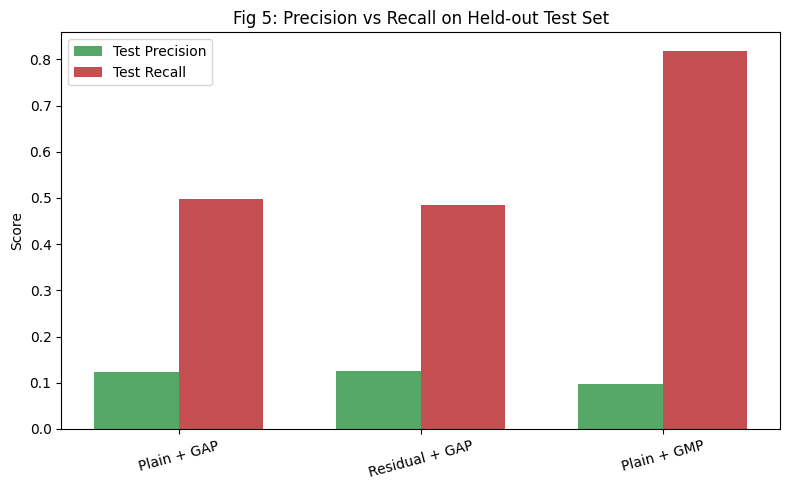

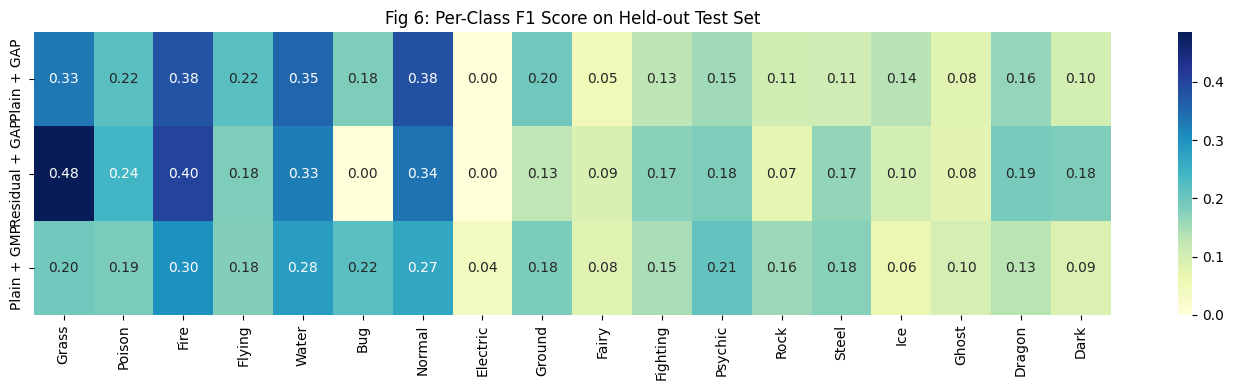

In [6]:
# --- 图 5：Test Precision vs Recall 对比图 ---
def plot_test_precision_recall(summary_raw_df):
    x = np.arange(len(summary_raw_df))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(
        x - width / 2,
        summary_raw_df["test_precision"],
        width,
        label="Test Precision",
        color="#55A868",
    )
    plt.bar(
        x + width / 2,
        summary_raw_df["test_recall"],
        width,
        label="Test Recall",
        color="#C44E52",
    )

    plt.xticks(x, summary_raw_df["Experiment"], rotation=15)
    plt.ylabel("Score")
    plt.title("Fig 5: Precision vs Recall on Held-out Test Set")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig5_test_precision_recall.png", dpi=300, bbox_inches="tight")
    plt.show()


# --- 图 6：Per-Class F1 热力图 ---
def plot_test_class_f1_heatmap(summary_raw_df, class_names):
    matrix = np.vstack(summary_raw_df["test_class_f1"].values)

    plt.figure(figsize=(14, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        xticklabels=class_names,
        yticklabels=summary_raw_df["Experiment"],
        cbar=True,
    )

    plt.title("Fig 6: Per-Class F1 Score on Held-out Test Set")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig6_test_class_f1_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_test_precision_recall(summary_raw_df)
plot_test_class_f1_heatmap(summary_raw_df, class_names)


In [ ]:
def package_current_experiment(exp_name=None, note=""):
    """
    将本次实验的所有产物封装到独立文件夹中。
    
    Parameters:
    -----------
    exp_name : str, optional
        实验名称，默认使用当前时间戳。
    note : str
        备注信息，会写入 config.txt 中。
    
    Returns:
    --------
    exp_dir : Path
        封装后的实验文件夹路径。
    """
    from pathlib import Path
    import pandas as pd
    
    # 创建实验根目录
    experiments_root = BASE_DIR / "experiments"
    experiments_root.mkdir(exist_ok=True)
    
    # 生成实验文件夹名
    if exp_name is None:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        exp_name = f"exp_{timestamp}_epoch{EPOCHS}_thr{THRESHOLDS[0]:.2f}_{THRESHOLDS[-1]:.2f}"
    exp_dir = experiments_root / exp_name
    exp_dir.mkdir(exist_ok=True)
    
    print(f"📦 正在封装实验到: {exp_dir}")
    
    # 1. 保存当前 notebook 副本
    notebook_src = Path.cwd() / "2_2.ipynb"
    if notebook_src.exists():
        shutil.copy2(notebook_src, exp_dir / "2_2.ipynb")
        print("   ✅ 已复制 notebook")
    
    # 2. 复制模型文件
    model_src_dir = MODEL_DIR
    model_dst_dir = exp_dir / "model"
    if model_src_dir.exists():
        shutil.copytree(model_src_dir, model_dst_dir, dirs_exist_ok=True)
        print("   ✅ 已复制模型文件")
    
    # 3. 复制图表
    fig_src_dir = FIG_DIR
    fig_dst_dir = exp_dir / "figures"
    if fig_src_dir.exists():
        shutil.copytree(fig_src_dir, fig_dst_dir, dirs_exist_ok=True)
        print("   ✅ 已复制图表")
    
    # 4. 保存汇总表格
    #    (需确保 summary_df, summary_raw_df, history_df 已在全局变量中)
    try:
        summary_df.to_csv(exp_dir / "summary_df.csv", index=False)
        summary_raw_df.to_csv(exp_dir / "summary_raw_df.csv", index=False)
        history_df.to_csv(exp_dir / "history_df.csv", index=False)
        print("   ✅ 已保存汇总表格")
    except NameError:
        print("   ⚠️ 未找到汇总表格变量，请先运行 main()")
    
    # 5. 保存实验配置信息
    config_info = {
        "experiment_name": exp_name,
        "timestamp": datetime.datetime.now().isoformat(),
        "note": note,
        "SEED": SEED,
        "TEST_RATIO": TEST_RATIO,
        "N_SPLITS": N_SPLITS,
        "BATCH_SIZE": BATCH_SIZE,
        "LR": LR,
        "EPOCHS": EPOCHS,
        "THRESHOLDS": THRESHOLDS.tolist() if isinstance(THRESHOLDS, np.ndarray) else THRESHOLDS,
        "SMOKE_TEST": SMOKE_TEST,
        "DEVICE": str(DEVICE),
    }
    with open(exp_dir / "config.json", "w") as f:
        json.dump(config_info, f, indent=2)
    print("   ✅ 已保存配置文件")
    
    print(f"\n✨ 实验封装完成！文件夹: {exp_dir}")
    return exp_dir

In [ ]:
# 运行此单元格以封装本次实验结果
# 您可以在 note 参数中填写备注（例如 "baseline_epoch100"）
package_current_experiment(note="baseline_run")

In [ ]:
def aggregate_experiments(experiments_root=None):
    """汇总所有实验的结果表格。"""
    if experiments_root is None:
        experiments_root = BASE_DIR / "experiments"
    
    all_raw_dfs = []
    for config_file in experiments_root.glob("*/config.json"):
        exp_dir = config_file.parent
        raw_csv = exp_dir / "summary_raw_df.csv"
        if not raw_csv.exists():
            continue
        
        df = pd.read_csv(raw_csv)
        # 添加实验标识列
        df.insert(0, "experiment_folder", exp_dir.name)
        
        # 读取配置信息并附加到每一行
        with open(config_file, "r") as f:
            config = json.load(f)
        for key in ["EPOCHS", "THRESHOLDS", "note"]:
            df[key] = str(config.get(key, ""))
        
        all_raw_dfs.append(df)
    
    if not all_raw_dfs:
        print("⚠️ 未找到任何实验数据。")
        return None
    
    combined = pd.concat(all_raw_dfs, ignore_index=True)
    # 按实验文件夹排序
    combined = combined.sort_values(["experiment_folder", "Experiment"])
    return combined

# 运行汇总
agg_df = aggregate_experiments()
if agg_df is not None:
    print("📊 所有实验结果汇总：")
    display(agg_df)
    
    # 可选：保存汇总表
    agg_df.to_csv(BASE_DIR / "experiments/all_experiments_summary.csv", index=False)
    print("✅ 汇总表已保存至 experiments/all_experiments_summary.csv")